In [1]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import vector_normalize_dictionary_values, find_best_cnot_sequence_brute_force, find_best_cnot_sequence_multi_epoch
from quantum_functions import find_best_cnot_sequence_iterative_n_wise

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("merged_datasets_co_mo.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 8000 × 60
    obs: 'BatchID', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'

In [3]:
gl_source = ['TGFBR2', 'FLT4', 'KDR', 'PDGFB']
gl_recv = ['TGFB1', 'NRP1', 'PDGFRB']

In [4]:
from scipy.sparse import issparse

ict1 = (adata.obs["CellType"] == 'CAF') & (adata.obs['Batch2'] == 'Co')
ict2 = (adata.obs["CellType"] == 'Fibroblasts') & (adata.obs['Batch2'] == 'Co')

adata_ct1_co = adata[ict1, gl_source].copy()
adata_ct2_co = adata[ict2, gl_recv].copy()
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)


if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)


AnnData object with n_obs × n_vars = 2000 × 4
    obs: 'BatchID', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'BatchID', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [5]:

ict1 = (adata.obs["CellType"] == 'CAF') & (adata.obs['Batch2'] == 'Mo')
ict2 = (adata.obs["CellType"] == 'Fibroblasts') & (adata.obs['Batch2'] == 'Mo')

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2000 × 4
    obs: 'BatchID', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'BatchID', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'


In [6]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

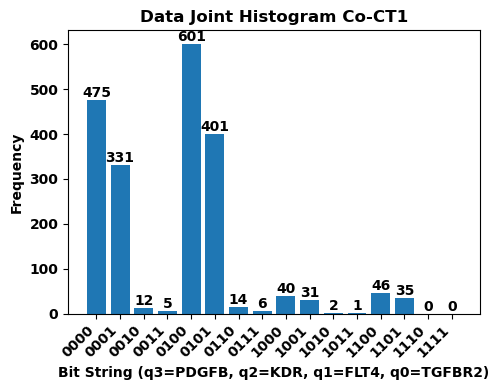

Joint Counts: Counter({'0100': 601, '0000': 475, '0101': 401, '0001': 331, '1100': 46, '1000': 40, '1101': 35, '1001': 31, '0110': 14, '0010': 12, '0111': 6, '0011': 5, '1010': 2, '1011': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101']


In [7]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_co_ct1.svg', title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

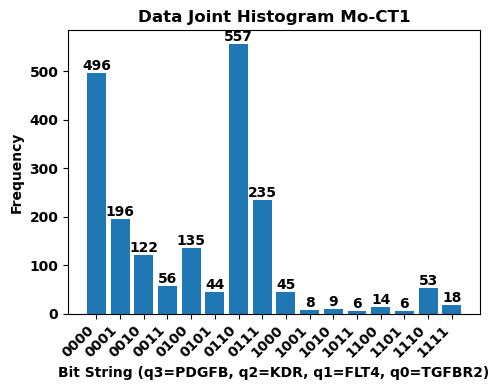

Joint Counts: Counter({'0110': 557, '0000': 496, '0111': 235, '0001': 196, '0100': 135, '0010': 122, '0011': 56, '1110': 53, '1000': 45, '0101': 44, '1111': 18, '1100': 14, '1010': 9, '1001': 8, '1101': 6, '1011': 6})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [8]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_mo_ct1.svg', title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

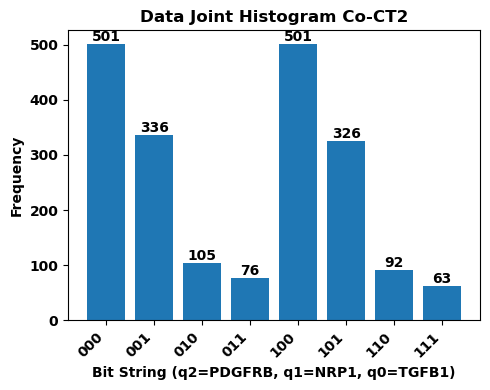

Joint Counts: Counter({'100': 501, '000': 501, '001': 336, '101': 326, '010': 105, '110': 92, '011': 76, '111': 63})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [9]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_co_ct2.svg', title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

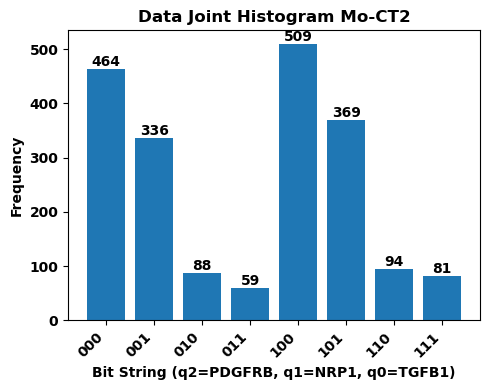

Joint Counts: Counter({'100': 509, '000': 464, '101': 369, '001': 336, '110': 94, '010': 88, '111': 81, '011': 59})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [10]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_mo_ct2.svg', title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [11]:
import numpy as np
# --- Function to normalize dictionary values ---
def vector_normalize_dictionary_values(input_dict):
    """Normalizes the values of a dictionary by dividing each value by the L2 norm of all values."""
    values = np.array(list(input_dict.values()), dtype=float)
    if values.size == 0:  # Handle empty dictionary
        return {}
    
    norm_val = np.linalg.norm(values)  # Calculate the L2 norm of the values

    if norm_val == 0:  # Avoid division by zero if all values are zero
        return {key: 0.0 for key in input_dict}

    normalized_dict = {}
    # Iterate through original dictionary items to maintain key order
    for i, (key, value) in enumerate(input_dict.items()):
        normalized_dict[key] = values[i] / norm_val
    return normalized_dict

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'0110': 557, '0000': 496, '0111': 235, '0001': 196, '0100': 135, '0010': 122, '0011': 56, '1110': 53, '1000': 45, '0101': 44, '1111': 18, '1100': 14, '1010': 9, '1001': 8, '1101': 6, '1011': 6})
State Set CT2 MO: Counter({'100': 509, '000': 464, '101': 369, '001': 336, '110': 94, '010': 88, '111': 81, '011': 59})
Interacted State Set CT1 CO: Counter({'0100': 601, '0000': 475, '0101': 401, '0001': 331, '1100': 46, '1000': 40, '1101': 35, '1001': 31, '0110': 14, '0010': 12, '0111': 6, '0011': 5, '1010': 2, '1011': 1})
Interacted State Set CT2 CO: Counter({'100': 501, '000': 501, '001': 336, '101': 326, '010': 105, '110': 92, '011': 76, '111': 63})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'0111': 0.2821598154336543, '0101': 0.05282992288970549, '0011': 0.06723808367780698, '0110': 0.6687787965810444, '0001': 0.23533329287232446, '0100': 0.16209180886614186, '0010': 0.146482968012

In [29]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)


all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= 0.02,
    nchoose=2,
    kl_tol = 0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 30
Initial KL-divergence: 4.201837
  - Starting CNOT search -
  - No. tested pairs: 870 | Added CNOTs [(4, 0), (2, 1)] | Best pair KL sum: 0.242783
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.242783
  - No. tested pairs: 756 | Added CNOTs [(1, 5), (5, 1)] | Best pair KL sum: 0.190536
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.190536
  - No. tested pairs: 650 | Added CNOTs [(1, 2), (0, 6)] | Best pair KL sum: 0.142836
  - Best single CNOT insertion KL Sum: 0.142790
  - Adopted new sequence. New KL Sum: 0.142790
  - No. tested pairs: 600 | Added CNOTs [(0, 6), (1, 2)] | Best pair KL sum: 0.137699
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.137699
  - No. tested pairs: 506 | Added CNOTs [(5, 6), (4, 2)] | Bes


--- Simulating and Plotting Histograms for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0100': 1695, '0101': 1032, '0000': 1268, '0110': 40, '1001': 6, '0001': 798, '0111': 38, '0010': 53, '0011': 42, '1100': 10, '1101': 7, '1000': 10, '1010': 1}
Counts for c_measure2: {'000': 1439, '101': 823, '100': 1600, '010': 126, '011': 61, '110': 121, '001': 735, '111': 95}


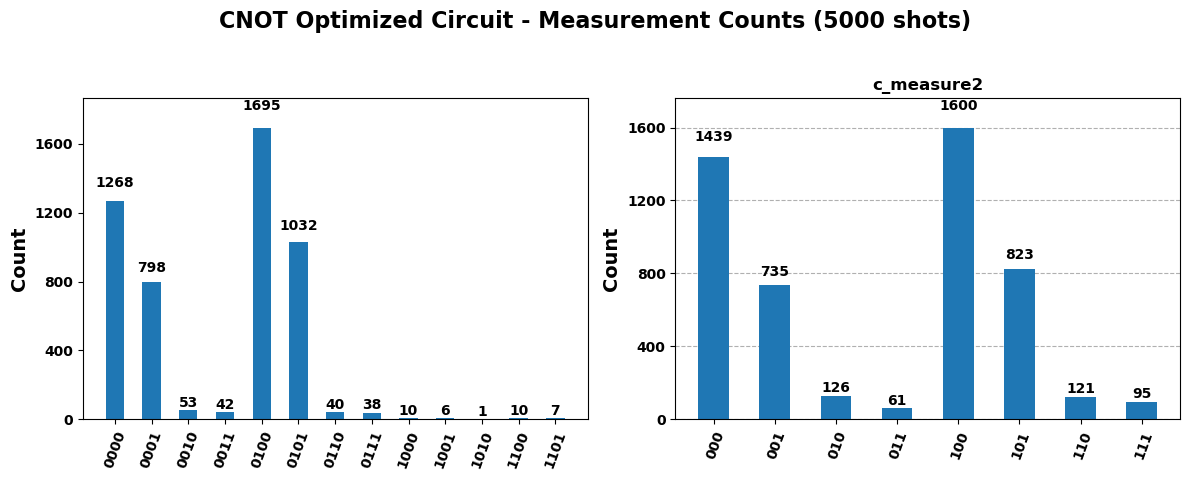

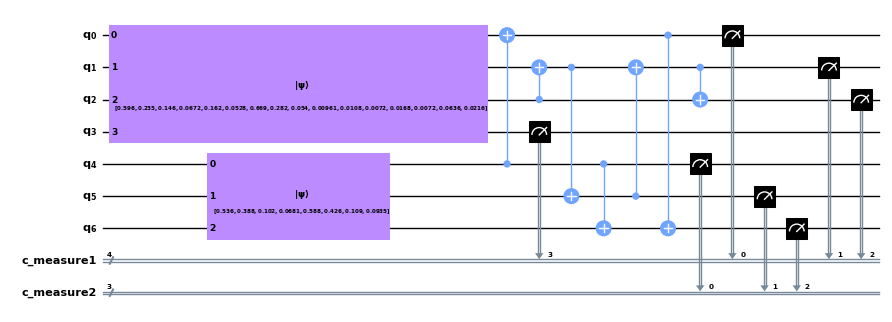

In [30]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

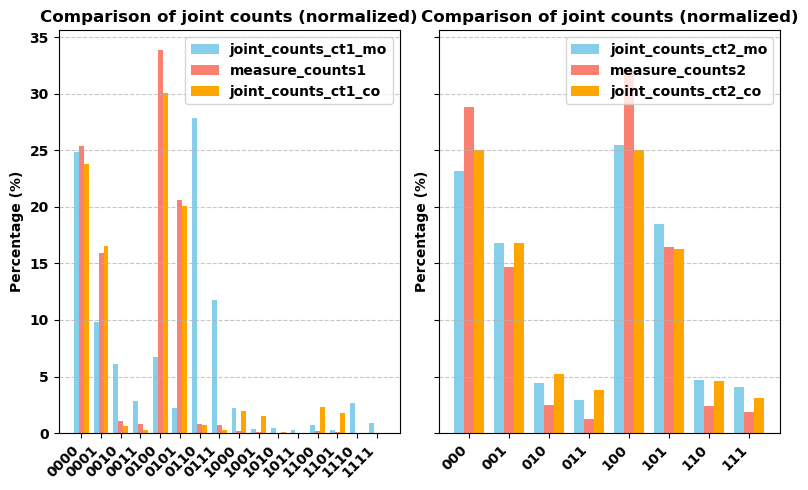

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')


In [32]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 10
min_greedy_depth = 1

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=0.02,
    kl_tol = 0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 24
Number of refined CNOT candidates: 30
Initial KL divergence: 4.26727891756288

--- Starting Epoch 1/10 (Addition) with CNOT: (2, 0) (KL: 4.906390) ---

--- Starting Epoch 2/10 (Addition) with CNOT: (2, 1) (KL: 0.331505) ---
    --> Found a better KL on this path: 0.264313 at depth 2 with added CNOT (4, 0)
    --> Found a better KL on this path: 0.229806 at depth 3 with added CNOT (4, 6)
    --> Found a better KL on this path: 0.220452 at depth 4 with added CNOT (0, 2)
  Epoch 2 best KL Sum: 0.220452
  --> Epoch 2 found a new overall best KL Sum: 0.220452

--- Starting Epoch 3/10 (Addition) with CNOT: (0, 5) (KL: 4.357393) ---

--- Starting Epoch 4/10 (Addition) with CNOT: (5, 6) (KL: 4.159410) ---
    --> Found a better KL on this path: 0.296603 at depth 2 with added CNOT (2, 1)
    --> Found a better KL on this path: 0.253594 at depth 3 with added CNOT (4, 0)


--- Simulating and Plotting Histograms for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0000': 1174, '0010': 75, '0100': 1570, '0001': 795, '0101': 1143, '0110': 90, '0011': 58, '0111': 50, '1000': 14, '1101': 13, '1100': 13, '1001': 4, '1110': 1}
Counts for c_measure2: {'000': 1420, '100': 1687, '110': 64, '101': 805, '001': 913, '010': 43, '111': 42, '011': 26}


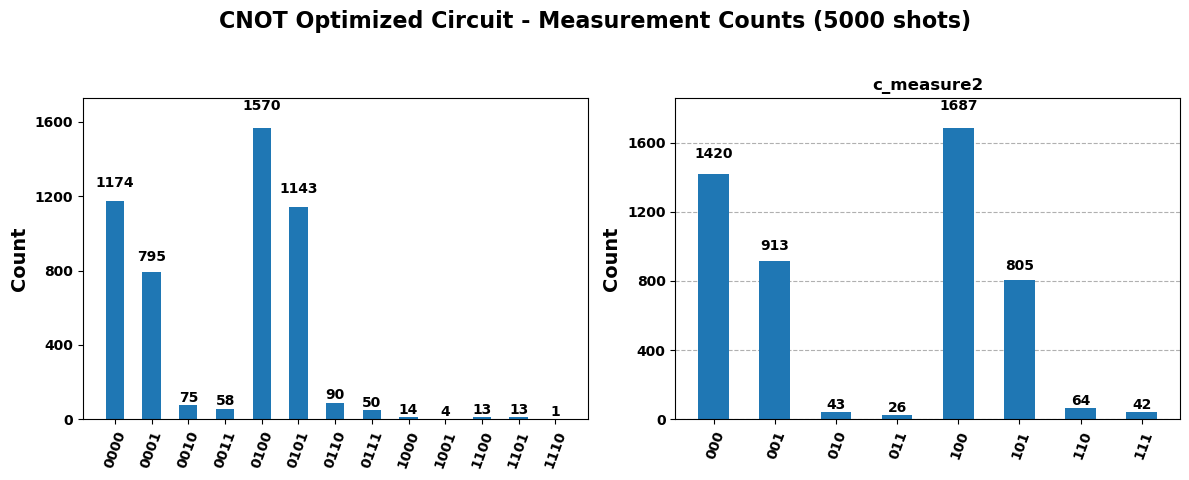

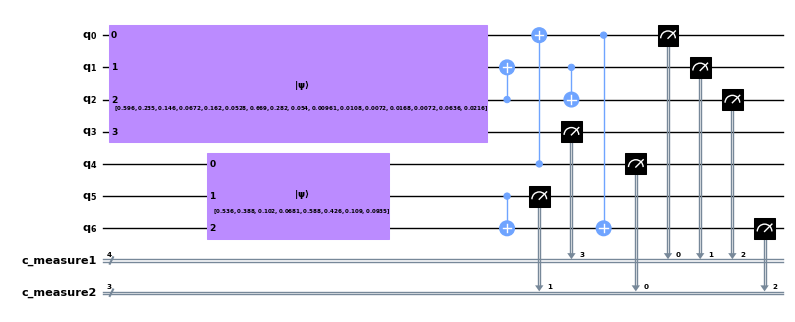

In [33]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

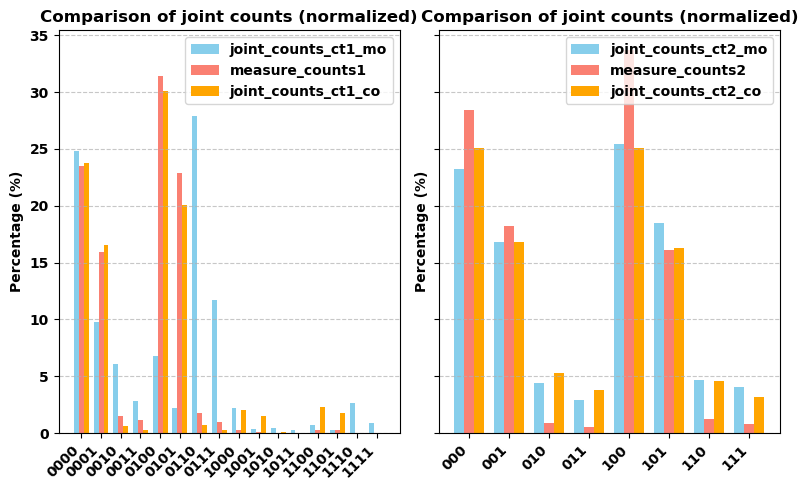

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (5 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.3047', '3.0697', '1.3227', '0.3872', '0.0427']
CRX Angle Optimization took: 14.29 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.3047', '3.0697', '1.3227', '0.3872', '0.0427']
  Minimum Combined KL Divergence with Optimized CRX: 0.270385


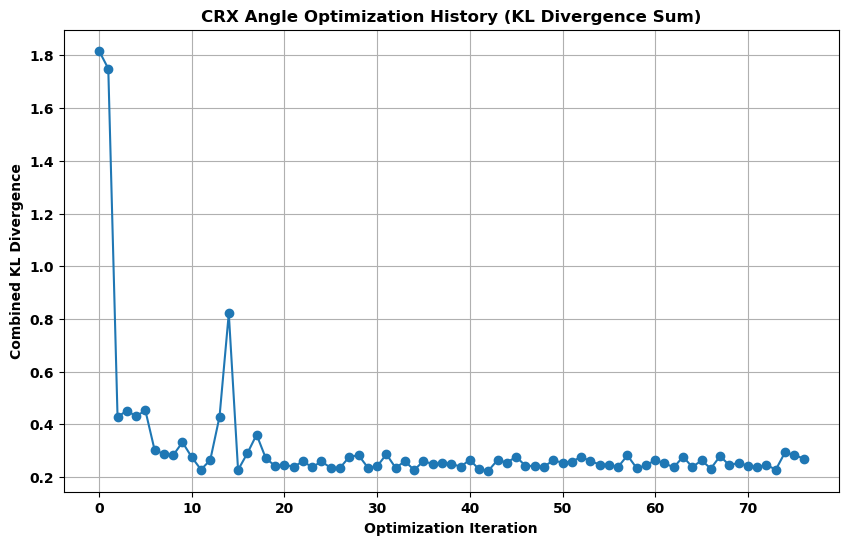


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                        ├»
«              │                                                                                                                                                         │»
«         q_1: ┤1                                                                                                                     

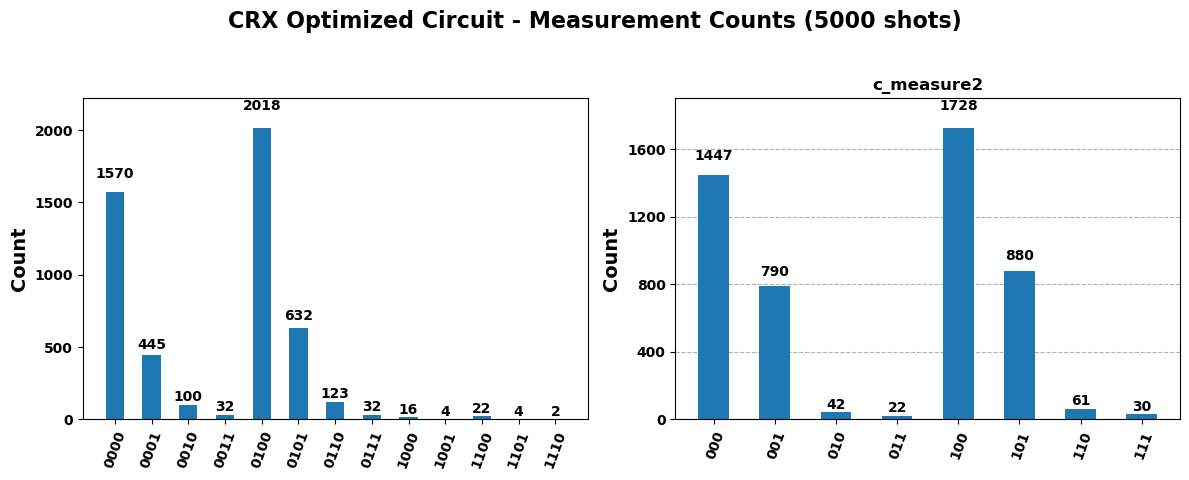

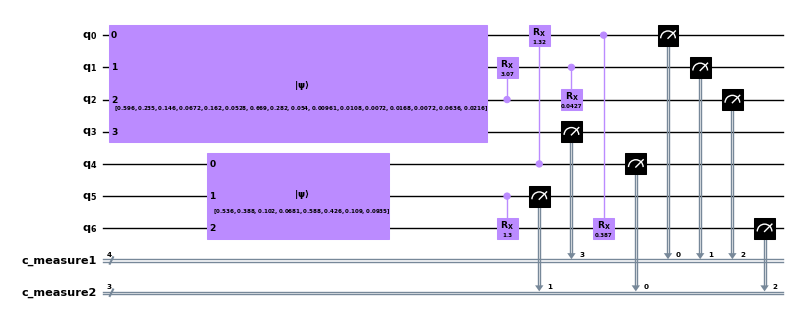

In [35]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.5)

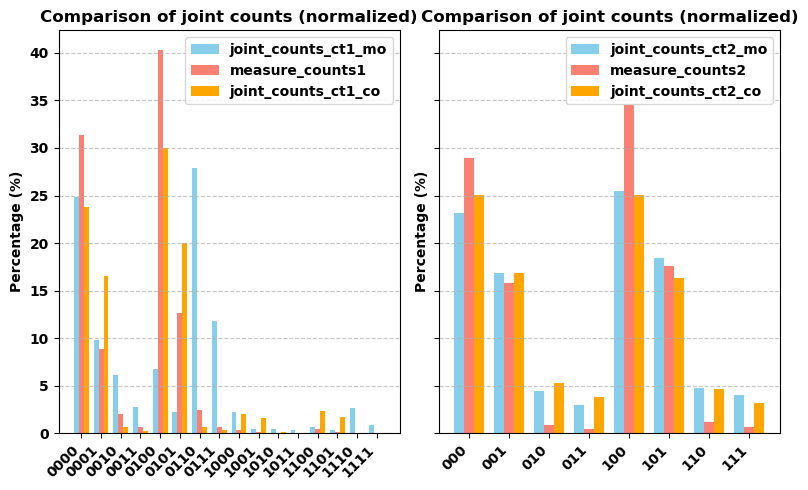

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts_anglkes.svg')
